<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/Notebook07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1
from google.colab import drive
drive.mount('/content/drive')
import numpy as np, pandas as pd, pickle, matplotlib.pyplot as plt, seaborn as sns, warnings
from scipy.stats import kendalltau, pearsonr
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
BASE = '/content/drive/MyDrive/xai-ids'
print('✅ Setup complete')

Mounted at /content/drive
✅ Setup complete


In [2]:
# CELL 2
with open(f'{BASE}/results/shap_values.pkl','rb') as f: shap_data = pickle.load(f)
with open(f'{BASE}/results/lime_results.pkl','rb') as f: lime_results = pickle.load(f)

shap_class1   = shap_data['shap_class1']
feature_names = shap_data['feature_names']
print(f'✅ SHAP: {shap_class1.shape} | LIME: {len(lime_results)} samples')
print(f'   Features: {feature_names[:5]}...')

✅ SHAP: (200, 41) | LIME: 30 samples
   Features: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes']...


In [3]:
# CELL 3
def parse_lime_feat(cond): return cond.split(' ')[0]

comparison_results = []
for i, lime_exp in enumerate(lime_results):
    lime_map  = {parse_lime_feat(f): w for f, w in lime_exp['explanation']}
    shap_map  = {feature_names[j]: float(shap_class1[i][j]) for j in range(len(feature_names))}
    common    = list(set(lime_map) & set(shap_map))
    if len(common) < 3: continue

    sv = np.array([abs(shap_map[f]) for f in common])
    lv = np.array([abs(lime_map[f]) for f in common])
    tau, _   = kendalltau(sv, lv)
    pear, _  = pearsonr(sv, lv)

    comparison_results.append({
        'sample': i, 'actual': lime_exp['actual'], 'predicted': lime_exp['predicted'],
        'confidence': lime_exp['confidence'], 'n_common': len(common),
        'kendall_tau': tau, 'pearson_r': pear,
        'correct_pred': lime_exp['actual'] == lime_exp['predicted']
    })

comparison_df = pd.DataFrame(comparison_results)
print(f'✅ Comparison computed for {len(comparison_df)} samples')
print(f'   Avg common features: {comparison_df["n_common"].mean():.1f}')

✅ Comparison computed for 30 samples
   Avg common features: 6.7


In [4]:
# CELL 4 — Statistics
tau_mean = comparison_df['kendall_tau'].mean()
tau_std  = comparison_df['kendall_tau'].std()
pear_mean = comparison_df['pearson_r'].mean()

print('='*60)
print('SHAP vs LIME AGREEMENT')
print('='*60)
print(f"Kendall's Tau  — mean: {tau_mean:.4f}  std: {tau_std:.4f}  median: {comparison_df['kendall_tau'].median():.4f}")
print(f"Pearson r      — mean: {pear_mean:.4f}")

if comparison_df['correct_pred'].any() and (~comparison_df['correct_pred']).any():
    tc = comparison_df.loc[comparison_df['correct_pred'],  'kendall_tau'].mean()
    ti = comparison_df.loc[~comparison_df['correct_pred'], 'kendall_tau'].mean()
    print(f'Tau (correct preds):   {tc:.4f}')
    print(f'Tau (incorrect preds): {ti:.4f}')

level = 'STRONG' if tau_mean>0.7 else 'MODERATE' if tau_mean>0.5 else 'WEAK' if tau_mean>0.3 else 'VERY WEAK' if tau_mean>0 else 'NEGATIVE'
print(f'\nConclusion: {level} agreement (τ = {tau_mean:.4f} ± {tau_std:.4f})')
if tau_mean < 0:
    print('SHAP and LIME rank features in opposite orders on average.')
    print('This is a substantive finding — discuss in your report.')

SHAP vs LIME AGREEMENT
Kendall's Tau  — mean: 0.3165  std: 0.3024  median: 0.3667
Pearson r      — mean: 0.1219
Tau (correct preds):   0.3262
Tau (incorrect preds): 0.2679

Conclusion: WEAK agreement (τ = 0.3165 ± 0.3024)


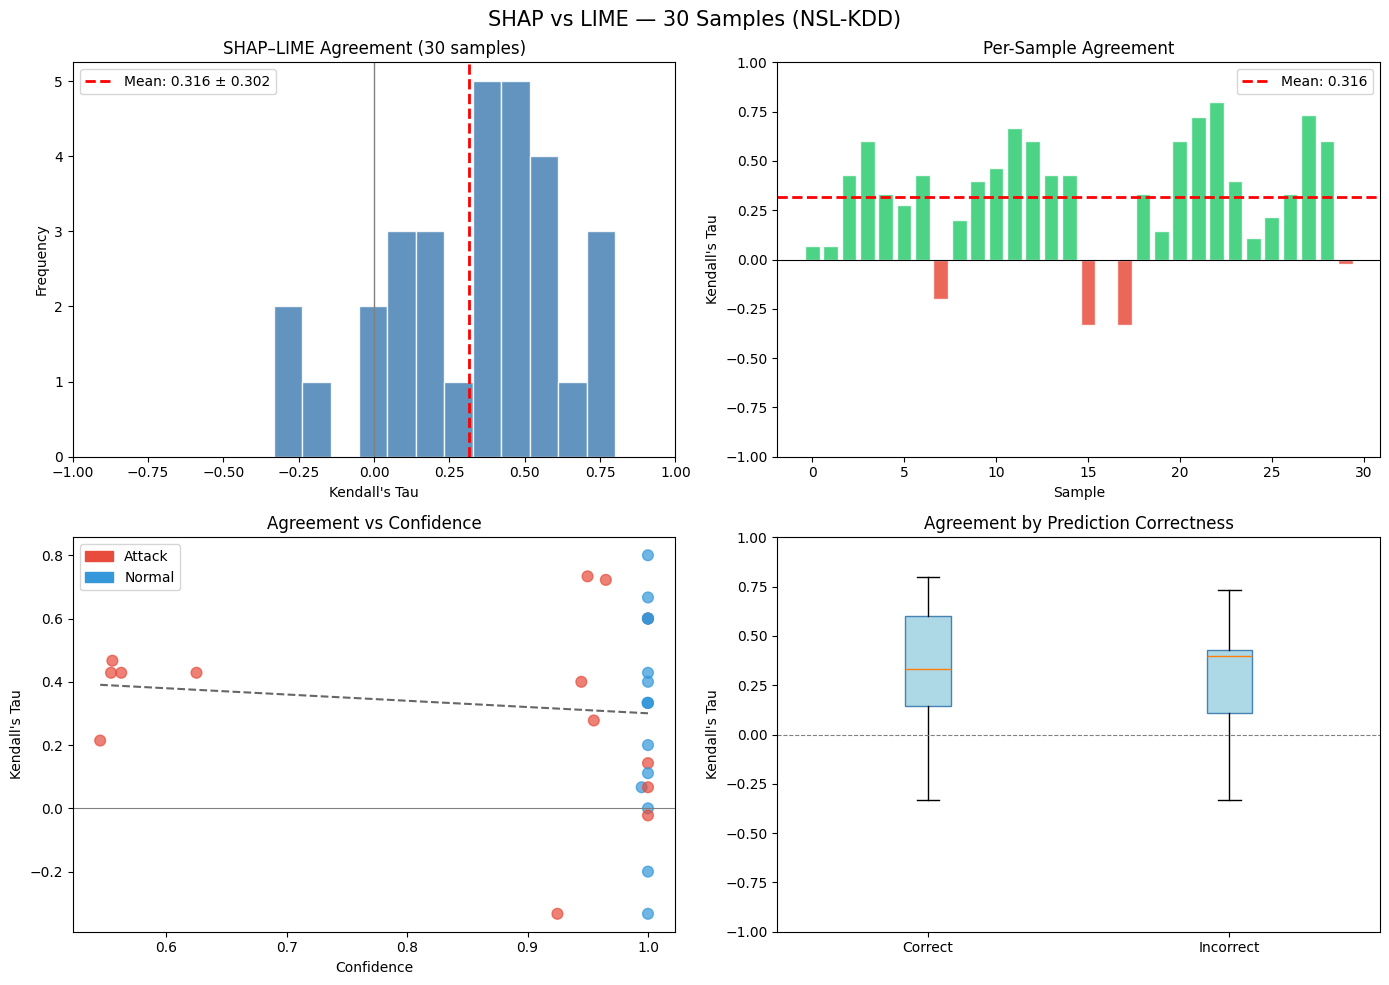

✅ Figure saved


In [5]:
# CELL 5 — Visualisation
fig, axes = plt.subplots(2,2,figsize=(14,10))

axes[0,0].hist(comparison_df['kendall_tau'], bins=12, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].axvline(tau_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {tau_mean:.3f} ± {tau_std:.3f}')
axes[0,0].axvline(0, color='grey', linewidth=1)
axes[0,0].set_xlabel("Kendall's Tau"); axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title(f"SHAP–LIME Agreement ({len(comparison_df)} samples)"); axes[0,0].set_xlim(-1,1); axes[0,0].legend()

bar_c = ['#2ecc71' if t>0 else '#e74c3c' for t in comparison_df['kendall_tau']]
axes[0,1].bar(comparison_df['sample'], comparison_df['kendall_tau'], color=bar_c, edgecolor='white', alpha=0.85)
axes[0,1].axhline(tau_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {tau_mean:.3f}')
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_xlabel('Sample'); axes[0,1].set_ylabel("Kendall's Tau")
axes[0,1].set_title('Per-Sample Agreement'); axes[0,1].set_ylim(-1,1); axes[0,1].legend()

sc_c = ['#e74c3c' if a=='Attack' else '#3498db' for a in comparison_df['actual']]
axes[1,0].scatter(comparison_df['confidence'], comparison_df['kendall_tau'], c=sc_c, alpha=0.7, s=60)
if len(comparison_df) > 2:
    z = np.polyfit(comparison_df['confidence'], comparison_df['kendall_tau'], 1)
    xl = np.linspace(comparison_df['confidence'].min(), comparison_df['confidence'].max(), 100)
    axes[1,0].plot(xl, np.poly1d(z)(xl), 'k--', alpha=0.6, label='Trend')
axes[1,0].axhline(0, color='grey', linewidth=0.8)
axes[1,0].set_xlabel('Confidence'); axes[1,0].set_ylabel("Kendall's Tau")
axes[1,0].set_title('Agreement vs Confidence')
axes[1,0].legend(handles=[Patch(color='#e74c3c',label='Attack'),Patch(color='#3498db',label='Normal')])

box_data  = [comparison_df.loc[comparison_df['correct_pred'],'kendall_tau'].values,
             comparison_df.loc[~comparison_df['correct_pred'],'kendall_tau'].values]
box_labels = ['Correct','Incorrect']
box_data   = [b for b in box_data if len(b)>0]
box_labels = box_labels[:len(box_data)]
axes[1,1].boxplot(box_data, labels=box_labels, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', color='steelblue'))
axes[1,1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1,1].set_ylabel("Kendall's Tau"); axes[1,1].set_title('Agreement by Prediction Correctness'); axes[1,1].set_ylim(-1,1)

plt.suptitle(f'SHAP vs LIME — {len(comparison_df)} Samples (NSL-KDD)', fontsize=15)
plt.tight_layout()
plt.savefig(f'{BASE}/results/figures/shap_vs_lime_comparison.png', dpi=300, bbox_inches='tight')
plt.show(); print('✅ Figure saved')

In [6]:
# CELL 6 — Save
comparison_df.to_csv(f'{BASE}/results/metrics/xai_comparison.csv', index=False)
print('✅ XAI comparison results saved')
print(f'\nSummary: τ = {tau_mean:.4f} ± {tau_std:.4f}  |  Agreement level: {level}')

✅ XAI comparison results saved

Summary: τ = 0.3165 ± 0.3024  |  Agreement level: WEAK
